##### Bivariate Analysis

    Dataset: titanic_dataset.csv

    1. Numerical vs categorical: scatter plot, correlation
    2. Numerical vs categorical: box plot, group statistics
    3. Numerical vs categorical: crosstab, countplot

1. Setup

In [1]:
%pip install -q numpy pandas matplotlib scipy seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

2. Load dataset

In [3]:
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
data.shape

(891, 15)

In [5]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [7]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Identify numerical and categorical columns
numerical_cols = ['age', 'fare', 'sibsp', 'parch']  # Explicitly specify numerical columns
categorical_cols = ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck','embark_town', 'alone']

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
Numerical Columns: ['age', 'fare', 'sibsp', 'parch']


In [9]:
data.head()[numerical_cols]

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [10]:
total_nulls = data[numerical_cols].isnull().sum()
print(total_nulls)

age      177
fare       0
sibsp      0
parch      0
dtype: int64


In [11]:
data_num = data[numerical_cols].dropna()

In [12]:
nulls_after_dropna = data_num.isnull().sum()
print(nulls_after_dropna)
print("Numerical columns with nulls after dropna:", (nulls_after_dropna > 0).sum())

age      0
fare     0
sibsp    0
parch    0
dtype: int64
Numerical columns with nulls after dropna: 0


In [13]:
data['survived_label'] = data['survived'].map({1: 'Yes', 0: 'No'})


In [14]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


3. Numerical vs Numerical

3.1 Scatter Plot

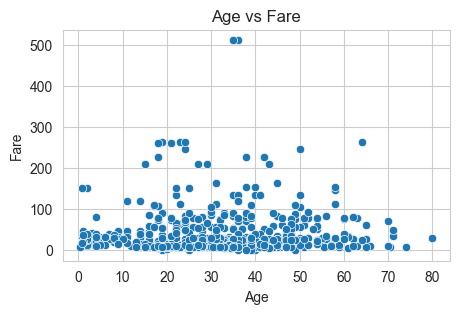

In [15]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=data_num['age'], y=data_num['fare'])
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

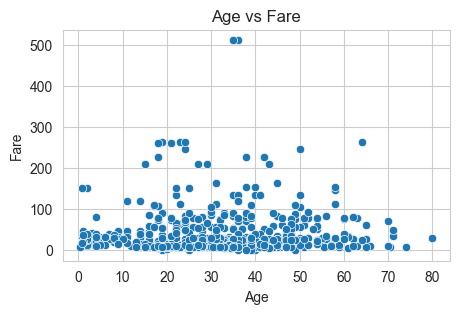

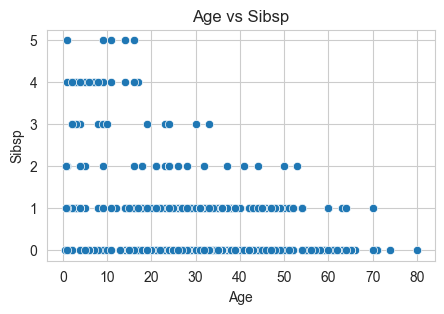

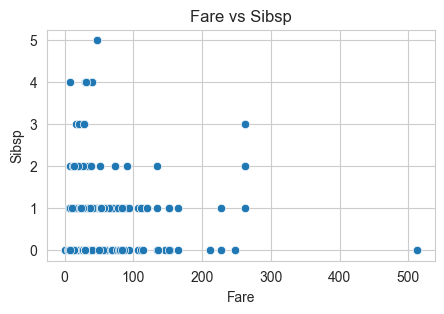

In [16]:
num_pairs = [
    ('age', 'fare'),
    ('age', 'sibsp'),
    ('fare', 'sibsp'),
]

for x_col, y_col in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=data_num[x_col], y=data_num[y_col])
    plt.title(f'{x_col.capitalize()} vs {y_col.capitalize()}')
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.show()

3.2 Correlation Matrix

In [17]:
print('Correlation Matrix')
corr_matrix = data_num.corr()
sns.set_style("whitegrid")
corr_matrix

Correlation Matrix


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [18]:
print('Pearson correlation with fare:')
for col in numerical_cols:
    if col != 'fare':
        corr, p_value = pearsonr(data_num['fare'], data_num[col])
        print(f'Correlation between fare and {col}: {corr:.2f} (p-value: {p_value:.4f})')

Pearson correlation with fare:
Correlation between fare and age: 0.10 (p-value: 0.0102)
Correlation between fare and sibsp: 0.14 (p-value: 0.0002)
Correlation between fare and parch: 0.21 (p-value: 0.0000)


4. Numerical vs categorical

4.1 Boxplots between survived_lavel vs age

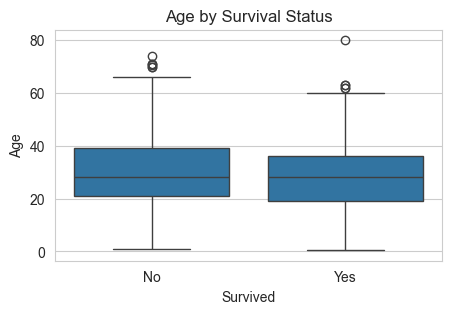

In [19]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['survived_label'], y=data['age'])
plt.title('Age by Survival Status')    
plt.xlabel('Survived')
plt.ylabel('Age')  
plt.show()

4.2 Boxplots between numerical vs categorical columns

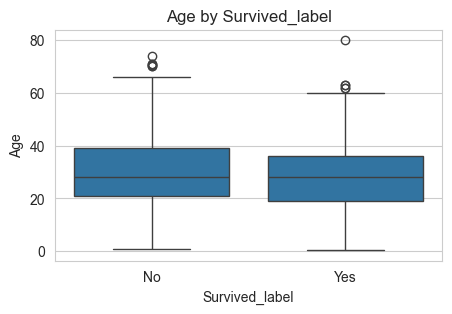

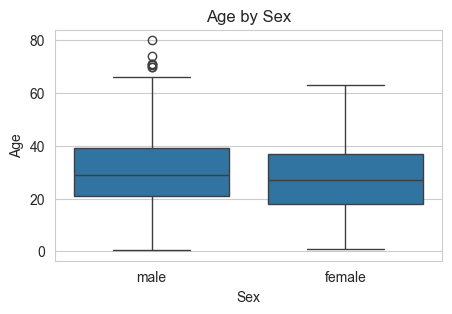

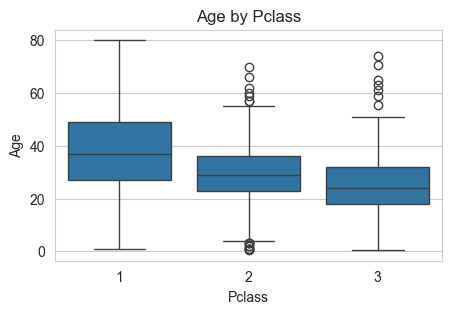

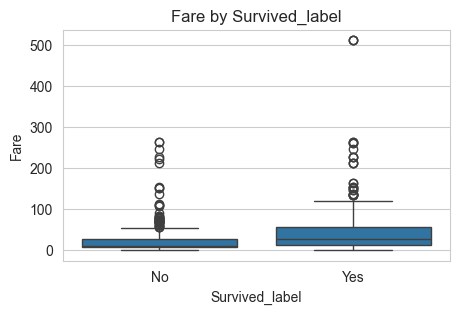

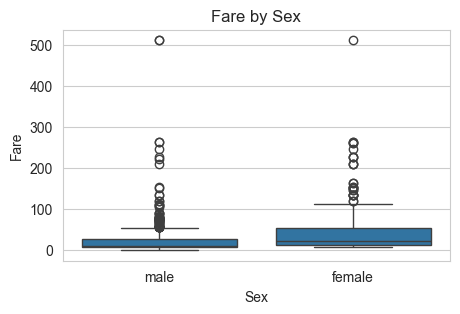

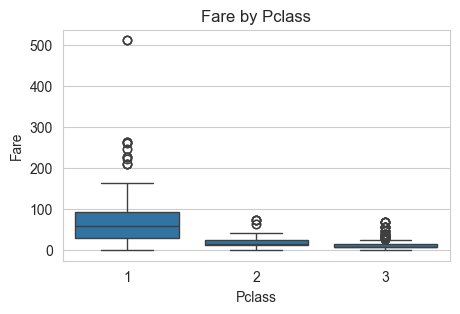

In [20]:
num_box = ['age', 'fare']
cat_box = ['survived_label', 'sex', 'pclass']

for num_col in num_box:
    for cat_col in cat_box:
        plt.figure(figsize=(5,3))
        sns.boxplot(x=data[cat_col], y=data[num_col])
        plt.title(f'{num_col.capitalize()} by {cat_col.capitalize()}')
        plt.xlabel(cat_col.capitalize())
        plt.ylabel(num_col.capitalize())
        plt.show()

4.3 Grouped Statistics

In [21]:
data[numerical_cols + ['survived_label']]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,No
1,38.0,71.2833,1,0,Yes
2,26.0,7.9250,0,0,Yes
3,35.0,53.1000,1,0,Yes
4,35.0,8.0500,0,0,No
...,...,...,...,...,...
886,27.0,13.0000,0,0,No
887,19.0,30.0000,0,0,Yes
888,NaN,23.4500,1,2,No
889,26.0,30.0000,0,0,Yes


In [22]:
data[numerical_cols + ['survived_label']]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,No
1,38.0,71.2833,1,0,Yes
2,26.0,7.9250,0,0,Yes
3,35.0,53.1000,1,0,Yes
4,35.0,8.0500,0,0,No
...,...,...,...,...,...
886,27.0,13.0000,0,0,No
887,19.0,30.0000,0,0,Yes
888,NaN,23.4500,1,2,No
889,26.0,30.0000,0,0,Yes


In [23]:
data[numerical_cols + ['survived_label']].groupby('survived_label').mean()

,age,fare,sibsp,parch
survived_label,,,,
No,30.626179,22.117887,0.553734,0.329690
Yes,28.343690,48.395408,0.473684,0.464912


In [24]:
for cat in ['survived_label', 'sex', 'pclass']:
    print(f'Group statistics for fare by {cat}:')
    print(data.groupby(cat)['fare'].mean())
    print('-'*50)

Group statistics for fare by survived_label:
survived_label
No     22.117887
Yes    48.395408
Name: fare, dtype: float64
--------------------------------------------------
Group statistics for fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64
--------------------------------------------------
Group statistics for fare by pclass:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
--------------------------------------------------


In [25]:
group_fare = data.groupby(['survived_label', 'sex', 'pclass'])['fare'].mean().reset_index()

top_row = group_fare.loc[group_fare['fare'].idxmax()]

print(
    f"The most survived passengers are: class {top_row['pclass']} {top_row['sex']} "
)

The most survived passengers are: class 1 female 


5. Categorical Vs Categorical Features

5.1 Crosstab Examples

In [26]:
sex_counts = data['sex'].value_counts()

print("Total passengers:", len(data))
print("Male passengers:", sex_counts['male'])
print("Female passengers:", sex_counts['female'])

Total passengers: 891
Male passengers: 577
Female passengers: 314


In [27]:
print("Crosstab: Sex vs Survived")
pd.crosstab(data['sex'], data['survived_label'])

Crosstab: Sex vs Survived


survived_label,No,Yes
sex,,
female,81,233
male,468,109


In [28]:
print("Crosstab: Pclass vs Survived")
pd.crosstab(data['pclass'], data['survived_label'])

Crosstab: Pclass vs Survived


survived_label,No,Yes
pclass,,
1,80,136
2,97,87
3,372,119


5.2 Countplot

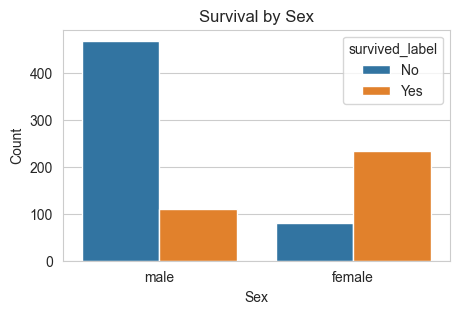

In [29]:
plt.figure(figsize=(5, 3))
sns.countplot(x=data['sex'], hue=data['survived_label'])
plt.title('Survival by Sex')    
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

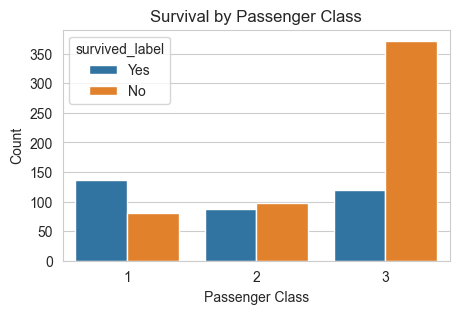

In [30]:
plt.figure(figsize=(5, 3))
sns.countplot(x=data['pclass'], hue=data['survived_label'])
plt.title('Survival by Passenger Class')    
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

##### Multivariate Analysis


        1. Pairplot
        2. Correlation Heatmap
        3. Cluster Map
        4. Interaction and sub-group pattern discovery

1. Pairplot

In [31]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [32]:
numerical_cols

['age', 'fare', 'sibsp', 'parch']

AttributeError: 'PairGrid' object has no attribute 'suptitle'

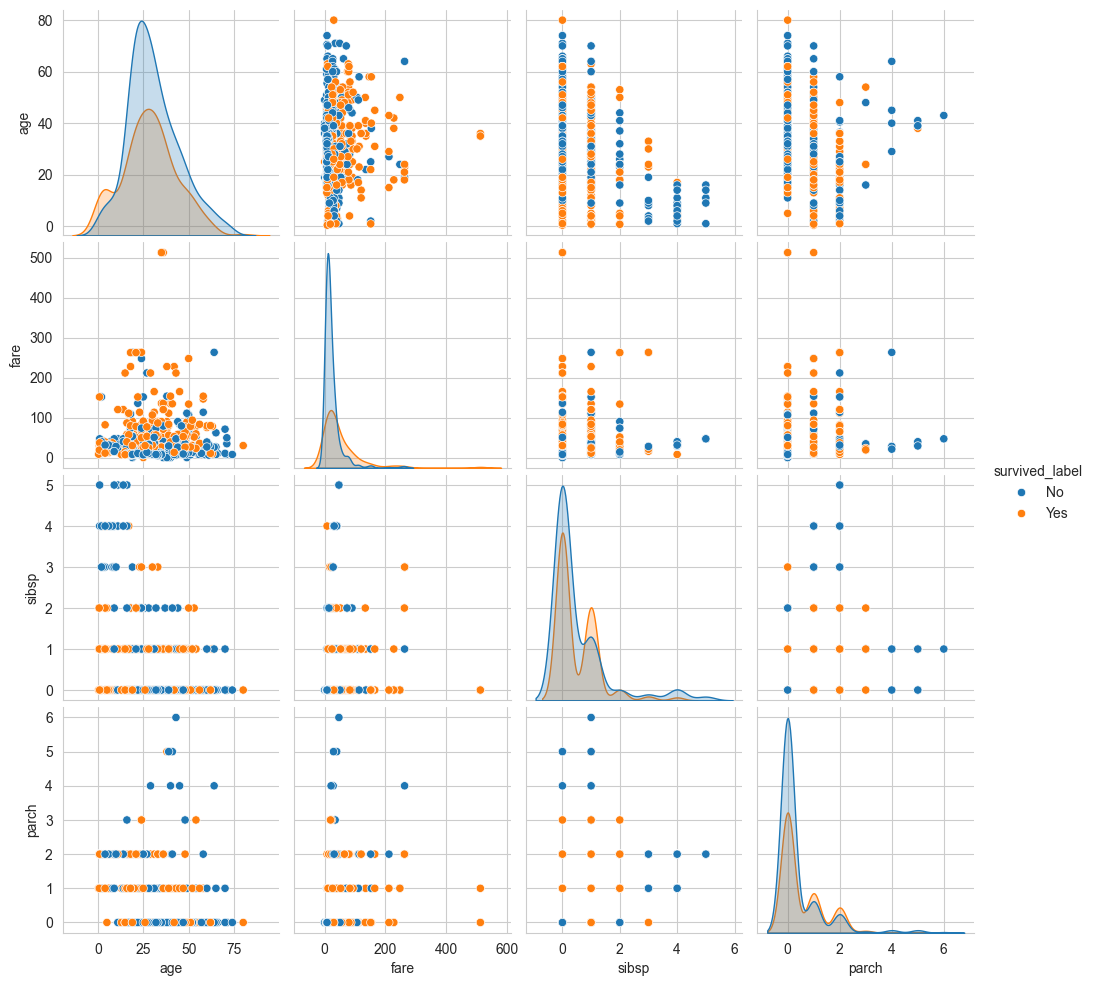

In [ ]:
pairplot_col = numerical_cols + ['survived_label']
data_pair = data[pairplot_col].dropna()

g = sns.pairplot(data_pair, hue='survived_label', diag_kind='kde')
g.fig.suptitle('Pairplot of Numerical Features by Survival Status', y=1.02)
plt.show()